In [1]:
!pip install xarray
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install cartopy
!pip install geopandas
!pip install netCDF4
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.3 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving air2mtemp2000_2021_India.nc to air2mtemp2000_2021_India.nc


In [3]:
with xr.open_dataset("air2mtemp2000_2021_India.nc") as dta:
    lat = dta['lat'].values.astype(np.float32)
    lon = dta['lon'].values.astype(np.float32)
    ttl = dta['time'].values
    var = dta['air']



In [4]:
time=pd.DataFrame(ttl,columns=["Time"])
lat0 = 28.
lat1 = 32.
lon0 = 77.
lon1 = 81.


In [5]:
box=np.array([lat0, lat1, lon0, lon1], dtype=np.float64)
idx_lat = np.where((lat >= box[0]) & (lat <= box[1]))[0].astype(np.int32)
idx_lon = np.where((lon >= box[2]) & (lon <= box[3]))[0].astype(np.int32)
print(idx_lat.shape[0], idx_lon.shape[0])


2 2


In [6]:
r = var[:,:, idx_lat, idx_lon].values
crop_data = xr.Dataset(
    {
        'air': (('time','level','lat', 'lon'), r[:,:, :, :]),
    },
      coords={
        'time': ttl,
        'lat': lat[idx_lat],
        'lon': lon[idx_lon]
    })


In [7]:
crop_data.to_netcdf('/content/cropped_new1.nc')
file = '/content/cropped_new1.nc'

fh = Dataset(file, mode='r')
ds1=Dataset(file)
ds=xr.open_dataset('/content/cropped_new1.nc')
print(ds,ds1)


<xarray.Dataset> Size: 193kB
Dimensions:  (time: 8036, level: 1, lat: 2, lon: 2)
Coordinates:
  * time     (time) datetime64[ns] 64kB 2000-01-01 2000-01-02 ... 2021-12-31
  * lat      (lat) float32 8B 31.43 29.52
  * lon      (lon) float32 8B 78.75 80.62
Dimensions without coordinates: level
Data variables:
    air      (time, level, lat, lon) float32 129kB ... <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(8036), level(1), lat(2), lon(2)
    variables(dimensions): float32 air(time, level, lat, lon), int64 time(time), float32 lat(lat), float32 lon(lon)
    groups: 


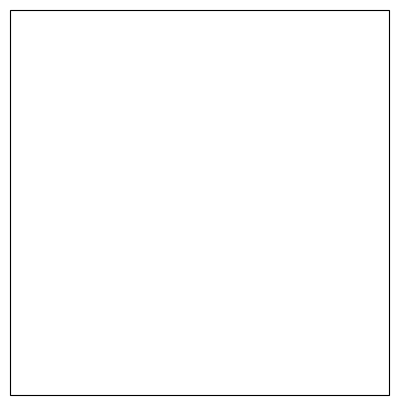

In [8]:
lat=ds["lat"].values
lon=ds["lon"].values
level=ds["level"].values
var=ds["air"][:,0,:,:].values

mean_var=var.mean(axis=0)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},figsize=(6,5))
ticksize=14
fontsize=16
ax.set_extent([min(lon),max(lon),min(lat),max(lat)],crs=ccrs.PlateCarree())

c=mean_var


In [9]:
mm = ax.contourf(lon,                   lat,                   c,                   transform=ccrs.PlateCarree(),                   cmap="RdBu_r",levels=50,extend='both')
ax.coastlines(resolution='110m');
ax.add_feature(cfeature.OCEAN.with_scale('110m'),zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.ylabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
im_ratio = c.shape[0]/c.shape[1]
cb = plt.colorbar(mm, shrink=0.9, drawedges='True',pad=0.03,fraction=0.04*im_ratio)
cb.ax.tick_params(size=10,labelsize=ticksize)
cb.set_label(label='air 2m (K)',size=fontsize-2)



/tmp/ipykernel_1320/979907758.py:15: UserWarning: Adding colorbar to a different Figure <Figure size 600x500 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(mm, shrink=0.9, drawedges='True',pad=0.03,fraction=0.04*im_ratio)


<Figure size 640x480 with 0 Axes>

In [10]:
TimeSeries= var.reshape((var.shape[0], var.shape[1]*var.shape[2]))
df=pd.DataFrame(TimeSeries,index=time["Time"])

file=df.to_csv('/content/cropped_new1.nc',sep='\t',index=False)
coordinates=np.zeros((max(len(lat),len(lon)),2))
coordinates[:]=np.nan
coordinates[:len(lat),0]=lat
coordinates[:len(lon),1]=lon
df_coordinate=pd.DataFrame(coordinates,columns=['lat','lon'])
df_coordinate.to_csv('/content/cropped_new1.nc',index=False)

In [11]:
Nodes=[]
for i in range((lat.shape[0])):
    for j in range((lon.shape[0])):

        node=[lat[i],lon[j]]
        Nodes.append(node)
Nodes=np.array(Nodes)
Nodes=pd.DataFrame({'Latitude':Nodes[:, 0], 'Longitude': Nodes[:, 1]})
print(Nodes)

    Latitude  Longitude
0  31.428101     78.750
1  31.428101     80.625
2  29.523399     78.750
3  29.523399     80.625


In [12]:
Nodes.to_csv('/content/cropped_new1.nc',index=False)
idx=np.where((Nodes.iloc[:,0]==31.428101 ) & (Nodes.iloc[:,1]==80.625))[0][0]
timeseries=df.iloc[:,idx]
type(timeseries)
timeseries=pd.Series(timeseries,name="temp")
type(timeseries)
timeseries=timeseries.to_frame()
print(timeseries)

                  temp
Time                  
2000-01-01  258.820007
2000-01-02  256.830017
2000-01-03  256.599976
2000-01-04  259.700012
2000-01-05  259.020020
...                ...
2021-12-27  253.029999
2021-12-28  254.962494
2021-12-29  257.924988
2021-12-30  256.070007
2021-12-31  259.255005

[8036 rows x 1 columns]


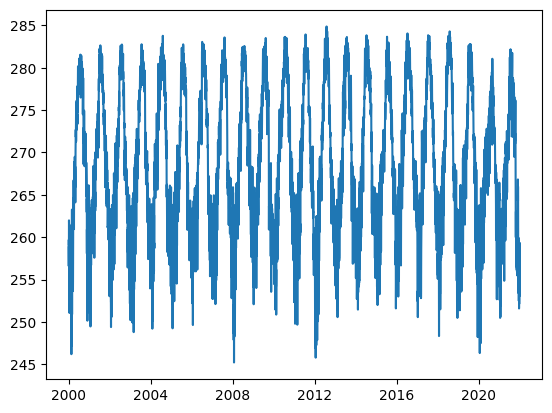

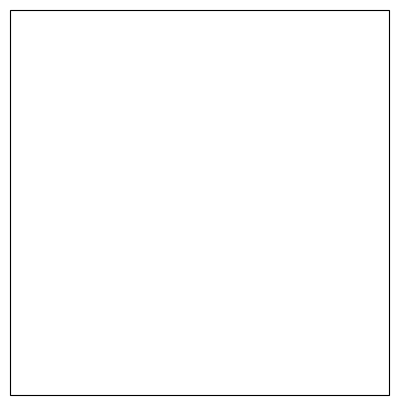

In [13]:
type(timeseries)
plt.plot(timeseries)
plt.show()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(8,5))

ticksize=14
fontsize=16
ax.set_extent([min(lon),max(lon),min(lat),max(lat)],crs=ccrs.PlateCarree())

In [14]:
c=mean_var
mm = ax.contourf(lon,                   lat,                   c,                   transform=ccrs.PlateCarree(),                   cmap="Reds",levels=10,extend='both')
ax.scatter(80.625,31.428101,color="k",s=100,transform=ccrs.PlateCarree(),label="Study point")
ax.coastlines(resolution='110m');
ax.add_feature(cfeature.OCEAN.with_scale('110m'),zorder=2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.ylabel_style = {'size': ticksize, 'color': 'k','family':'serif'}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
im_ratio = c.shape[0]/c.shape[1]
cb = fig.colorbar(mm, shrink=0.7,pad=0.05,ax=ax,orientation="vertical")
cb.ax.tick_params(size=10,labelsize=ticksize)
cb.set_label(label='air 2m (K)',size=fontsize-2)
ax.legend()


/tmp/ipykernel_1320/737892836.py:3: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(timeseries.index,timeseries,"-",color="k")


<Axes: xlabel='Time'>

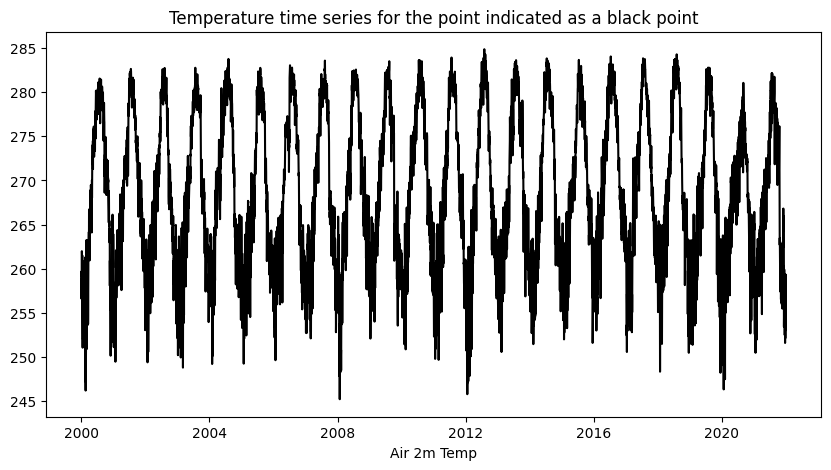

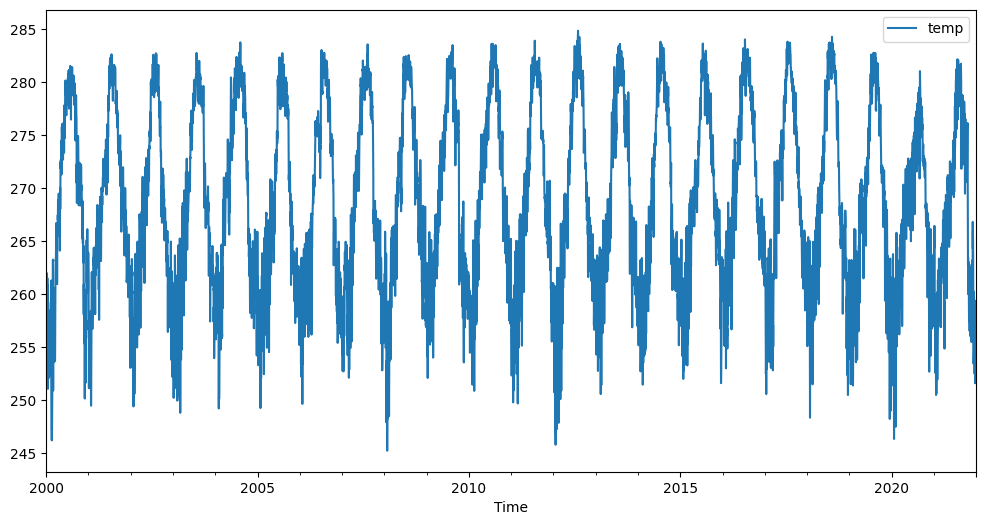

In [15]:
plt.figure(figsize=(10,5))

plt.plot_date(timeseries.index,timeseries,"-",color="k")

plt.xlabel("Time")
plt.xlabel("Air 2m Temp")

plt.title("Temperature time series for the point indicated as a black point")

len(timeseries)
timeseries.plot(figsize=[12,6])



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [17]:
dataset = timeseries.values
dataset = dataset.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [18]:
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

In [19]:
# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [47]:
model = Sequential()

model.add(LSTM(128,activation='relu', return_sequences=True, input_shape=(time_step, 1)))

model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))

model.add(LSTM(36, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

# Using Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 30, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 36)             │        14,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │           925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,215 (2.01 MB)

 Trainable params: 526,215 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=8
)

Epoch 1/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 113s 129ms/step - loss: 0.0232 - val_loss: 0.0079
Epoch 2/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 107s 133ms/step - loss: 0.0106 - val_loss: 0.0077
Epoch 3/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 109s 135ms/step - loss: 0.0088 - val_loss: 0.0061
Epoch 4/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 102s 127ms/step - loss: 0.0084 - val_loss: 0.0062
Epoch 5/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 146s 132ms/step - loss: 0.0079 - val_loss: 0.0055
Epoch 6/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - loss: 0.0072 - val_loss: 0.0055
Epoch 7/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 106s 132ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 8/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 102s 127ms/step - loss: 0.0066 - val_loss: 0.0052
Epoch 9/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 150s 137ms/step - loss: 0.0064 - val_loss: 0.0052
Epoch 10/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 99s 124ms/step - loss: 0.0061 - val_loss: 0.0051
Epoch 11/50
801/801 ━━━━━━━━━━━━━━━━━━━━ 105s 130ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 12/

In [49]:
y_pred = model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step


In [50]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.0029169688932597637


In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

0.05400897048879717


In [52]:
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [53]:
print(y_pred_actual[:10])

[[265.42532]
 [268.8312 ]
 [269.49298]
 [261.9188 ]
 [270.67218]
 [257.49368]
 [270.8938 ]
 [270.5036 ]
 [264.75085]
 [275.52115]]


In [54]:
for i in range(10):
    print(f"Actual: {y_test_actual[i]}, Predicted: {y_pred_actual[i]}")

Actual: [267.65253], Predicted: [265.42532]
Actual: [269.61], Predicted: [268.8312]
Actual: [271.33002], Predicted: [269.49298]
Actual: [262.64], Predicted: [261.9188]
Actual: [271.47], Predicted: [270.67218]
Actual: [263.78], Predicted: [257.49368]
Actual: [270.95], Predicted: [270.8938]
Actual: [269.45], Predicted: [270.5036]
Actual: [265.9875], Predicted: [264.75085]
Actual: [277.16], Predicted: [275.52115]


In [55]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


In [56]:
from sklearn.metrics import mean_squared_error
import math

rmse = math.sqrt(mean_squared_error(
    scaler.inverse_transform(y_test.reshape(-1,1)),
    test_predict
))

print("RMSE:", rmse)
rmse_percent = (rmse / (dataset.max() - dataset.min())) * 100
print("RMSE %:", rmse_percent)

import numpy as np

# Calculate error at each point
errors = scaler.inverse_transform(y_test.reshape(-1,1)) - test_predict

# RMSE at each point (absolute error)
rmse_series = np.sqrt(errors**2)

RMSE: 2.141455273517652
RMSE %: 5.4008965


In [57]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We need to reshape y for train_test_split to handle it correctly
X_train, X_test, y_train, y_test = train_test_split(X, y.reshape(y.shape[0], -1), test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6404, 30, 1)
X_test shape: (1602, 30, 1)
y_train shape: (6404, 1)
y_test shape: (1602, 1)


In [58]:
# Make predictions on the training and testing sets
train_pred_scaled = model.predict(X_train)
test_pred_scaled = model.predict(X_test)

print(f"train_pred_scaled shape: {train_pred_scaled.shape}")
print(f"test_pred_scaled shape: {test_pred_scaled.shape}")

201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step
train_pred_scaled shape: (6404, 1)
test_pred_scaled shape: (1602, 1)


In [59]:
from sklearn.metrics import mean_squared_error
import math

# Inverse transform the predictions and actual values for both train and test sets
# Note: y_train and y_test are already reshaped in train_test_split

train_pred_original = scaler.inverse_transform(train_pred_scaled)
y_train_original = scaler.inverse_transform(y_train)

test_pred_original = scaler.inverse_transform(test_pred_scaled)
y_test_original = scaler.inverse_transform(y_test)

# Calculate RMSE for training set
rmse_train = math.sqrt(mean_squared_error(y_train_original, train_pred_original))
print(f"Train RMSE: {rmse_train}")

# Calculate RMSE for testing set
rmse_test = math.sqrt(mean_squared_error(y_test_original, test_pred_original))
print(f"Test RMSE: {rmse_test}")

# Calculate RMSE percentage for training set
rmse_train_percent = (rmse_train / (dataset.max() - dataset.min())) * 100
print(f"Train RMSE %: {rmse_train_percent}")

# Calculate RMSE percentage for testing set
rmse_test_percent = (rmse_test / (dataset.max() - dataset.min())) * 100
print(f"Test RMSE %: {rmse_test_percent}")

Train RMSE: 2.1464501639391522
Test RMSE: 2.141455273517652
Train RMSE %: 5.41349458694458
Test RMSE %: 5.4008965492248535


In [60]:
# Compare train and test RMSE to diagnose underfitting/overfitting
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

# Define thresholds for assessment (these can be adjusted based on your domain knowledge)
rmse_diff_threshold = 0.1 # Absolute difference between train and test RMSE
high_rmse_threshold = 2.0 # Absolute RMSE value considered 'high'

if rmse_train > high_rmse_threshold and rmse_test > high_rmse_threshold:
    print("\nAssessment: The model might be *underfitting*. Both train and test RMSE are relatively high, indicating the model is not capturing the underlying patterns in the data well.")
elif rmse_train < rmse_test and (rmse_test - rmse_train) > rmse_diff_threshold:
    print(f"\nAssessment: The model might be *overfitting*. The test RMSE ({rmse_test:.4f}) is significantly higher than the train RMSE ({rmse_train:.4f}), suggesting the model learned the training data too well but struggles with unseen data.")
elif rmse_train <= rmse_test and (rmse_test - rmse_train) <= rmse_diff_threshold:
    print("\nAssessment: The model appears to be *well-fitted*. Both train and test RMSE are low and similar, indicating good generalization performance.")
else:
    print("\nAssessment: The model's fit is *acceptable*. The difference between train and test RMSE is small, and the overall RMSE values are reasonable.")


Train RMSE: 2.1465
Test RMSE: 2.1415

Assessment: The model might be *underfitting*. Both train and test RMSE are relatively high, indicating the model is not capturing the underlying patterns in the data well.


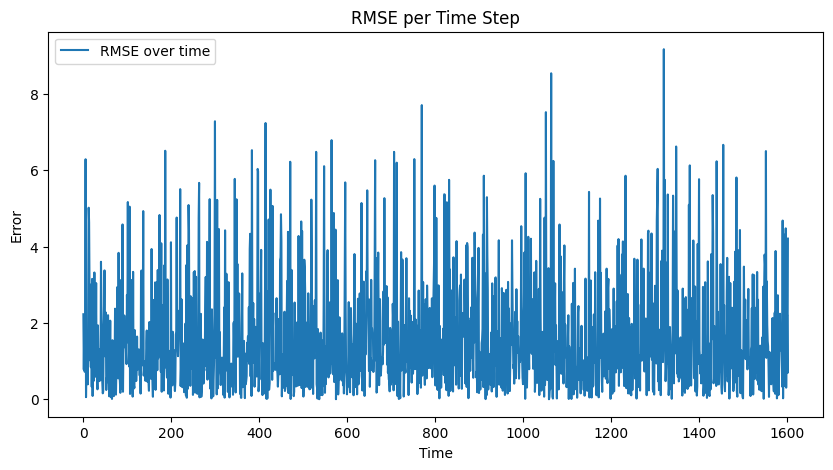

In [61]:
plt.figure(figsize=(10,5))
plt.plot(rmse_series, label="RMSE over time")
plt.title("RMSE per Time Step")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

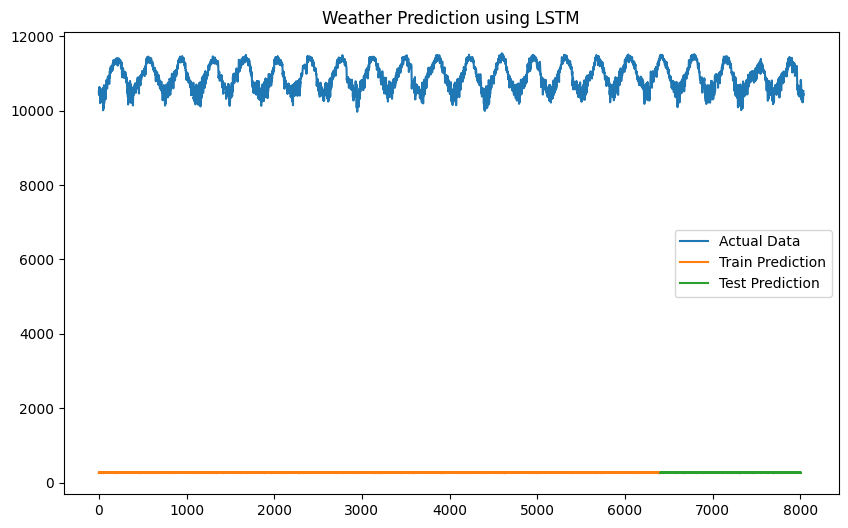

In [62]:
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Data')
plt.plot(range(len(train_predict)), train_predict, label='Train Prediction')
plt.plot(range(len(train_predict), len(train_predict)+len(test_predict)), test_predict, label='Test Prediction')

plt.legend()
plt.title("Weather Prediction using LSTM")
plt.show()

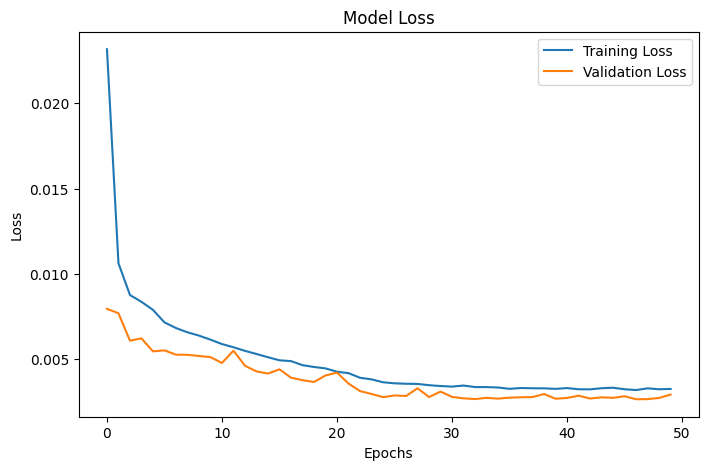

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

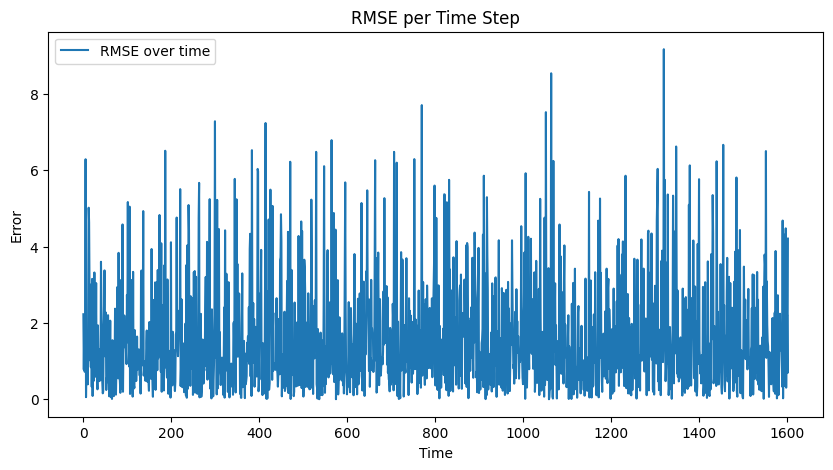

In [64]:
plt.figure(figsize=(10,5))
plt.plot(rmse_series, label="RMSE over time")
plt.title("RMSE per Time Step")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

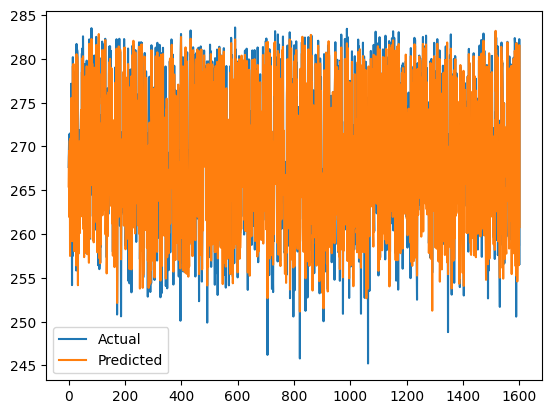

In [65]:
import matplotlib.pyplot as plt

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_actual, label="Predicted")
plt.legend()
plt.show()